# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

**1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?**

Linear models predict outcomes as an unbounded linear combination of features, which is problematic when the outcome has a restricted range like a probability between 0 and 1. General linear models apply a transformation via an activation function to map the linear prediction to the appropriate output space. This lets them model nonlinear relationships between features and outcomes while still remaining interpretable, and they produce predictions that respect the natural constraints of the target variable.

**2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.**

Cross entropy measures the difference between the predicted probability distribution and the true distribution. For binary outcomes it penalizes the model heavily when it assigns low probability to the correct class, pushing the model to produce well-calibrated probabilities. It is derived directly from the likelihood of the data under the logistic model, so minimizing cross entropy is equivalent to maximum likelihood estimation, making it a natural and principled choice.

**3. True or false, and explain: Logistic regression is a linear model.**

False. While the latent variable $b \cdot x$ is a linear function of the features, the predicted probability is a nonlinear transformation of that linear function via the sigmoid. The relationship between the features and the predicted probability is nonlinear, so logistic regression is not a linear model in the traditional sense.

**4. True or false, and explain: Logistic regression cannot be used for classification.**

False. Logistic regression predicts probabilities and those probabilities can be converted to class predictions by applying a threshold, typically 0.5. It is one of the most common classification methods and can be extended to multinomial classification for more than two classes.

**5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?**

No. Unlike linear regression where the coefficient directly represents the change in the predicted outcome for a 1 unit change in a feature, logistic regression coefficients represent the change in the log odds for a 1 unit change in the feature. The effect on the predicted probability depends on the current value of the prediction and is not constant across observations.

**6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.**

False. While logistic regression applies a nonlinear sigmoid transformation to its output, the latent variable is still a linear function of the input features and the decision boundary in feature space is still linear. If the true relationship between features and the outcome is nonlinear, feature engineering such as polynomial terms or interactions is still necessary to capture it.

**7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.**

False. Logistic regression is better suited for binary or categorical outcomes since it produces valid probabilities and respects the bounded nature of the target. For continuous outcomes OLS is more appropriate. Neither model is universally better and the right choice depends on the nature of the outcome variable and the goals of the analysis.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


Missing values:
 Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64
                   feature  coefficient
0                   Debtor     0.530625
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925


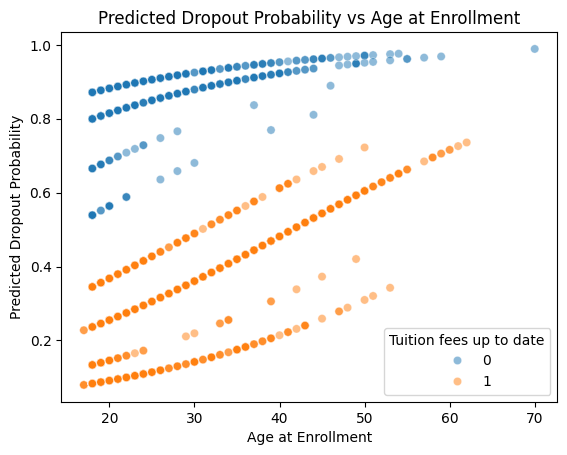

Tuition fees up to date
0    0.860675
1    0.248090
Name: dropout_prob, dtype: float64

Average difference in dropout probability: 0.6126


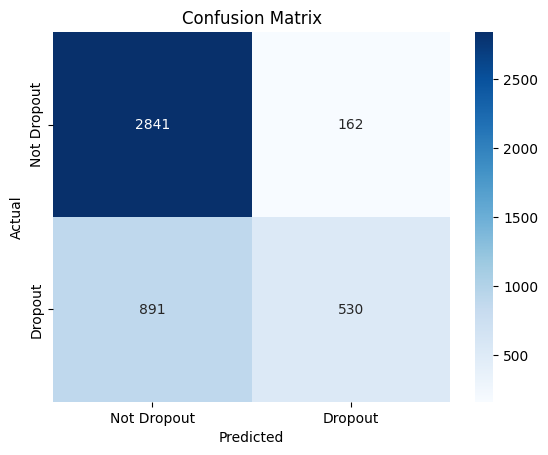

Accuracy: 0.7620


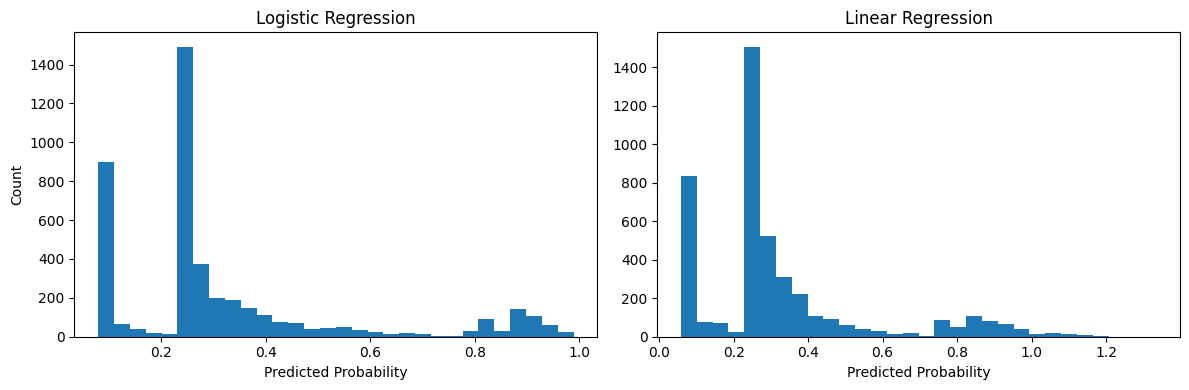

Linear model prediction range: 0.0583 to 1.3350


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


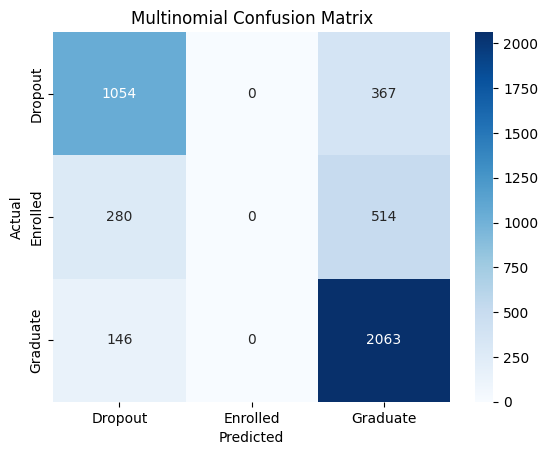

Accuracy: 0.7046
Classes predicted by hard classification: ['Dropout' 'Graduate']

Sample predicted probabilities:
    Dropout  Enrolled  Graduate
0  0.680547  0.210464  0.108989
1  0.695414  0.146043  0.158543
2  0.952988  0.041199  0.005813
3  0.117808  0.176983  0.705209
4  0.184227  0.212669  0.603104


In [13]:
df = pd.read_csv('data.csv', delimiter=';')

cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder',
        'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df = df[cols]
print('Missing values:\n', df.isnull().sum())

df['dropout'] = (df['Target'] == 'Dropout').astype(int)

features = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X = df[features]
y = df['dropout']

# Part 2 - Logistic regression
log_reg = LogisticRegression()
log_reg.fit(X, y)

coef_df = pd.DataFrame({'feature': features, 'coefficient': log_reg.coef_[0]})
print(coef_df)

# Part 3 - Predicted probabilities
proba = log_reg.predict_proba(X)[:, 1]
df['dropout_prob'] = proba

sns.scatterplot(data=df, x='Age at enrollment', y='dropout_prob',
                hue='Tuition fees up to date', alpha=0.5)
plt.title('Predicted Dropout Probability vs Age at Enrollment')
plt.xlabel('Age at Enrollment')
plt.ylabel('Predicted Dropout Probability')
plt.show()

avg_diff = df.groupby('Tuition fees up to date')['dropout_prob'].mean()
print(avg_diff)
print(f'\nAverage difference in dropout probability: {avg_diff[0] - avg_diff[1]:.4f}')

# Part 4 - Confusion matrix
y_pred = log_reg.predict(X)
cm = confusion_matrix(y, y_pred)
accuracy = accuracy_score(y, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Dropout', 'Dropout'],
            yticklabels=['Not Dropout', 'Dropout'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print(f'Accuracy: {accuracy:.4f}')

# Part 5 - Linear vs logistic comparison
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_proba = lin_reg.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(proba, bins=30)
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[1].hist(lin_proba, bins=30)
axes[1].set_title('Linear Regression')
axes[1].set_xlabel('Predicted Probability')
plt.tight_layout()
plt.show()
print(f'Linear model prediction range: {lin_proba.min():.4f} to {lin_proba.max():.4f}')

# Part 7 - Multinomial logistic regression
X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y_multi = df['Target']

multi_log = LogisticRegression(multi_class='multinomial', max_iter=1000)
multi_log.fit(X_multi, y_multi)

y_multi_pred = multi_log.predict(X_multi)
y_multi_proba = multi_log.predict_proba(X_multi)

cm_multi = confusion_matrix(y_multi, y_multi_pred)
accuracy_multi = accuracy_score(y_multi, y_multi_pred)

sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=multi_log.classes_,
            yticklabels=multi_log.classes_)
plt.title('Multinomial Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f'Accuracy: {accuracy_multi:.4f}')
print(f'Classes predicted by hard classification: {np.unique(y_multi_pred)}')
print(f'\nSample predicted probabilities:')
print(pd.DataFrame(y_multi_proba[:5], columns=multi_log.classes_))

**1.** There are no missing values in the dataset after filtering to the relevant columns. The binary dropout target maps Dropout to 1 and Graduate or Enrolled to 0.

**2.** Being a debtor (0.53) and older age at enrollment (0.05) both predict higher dropout probability, while having tuition up to date (-2.56) and holding a scholarship (-1.23) predict lower dropout probability. Being up to date on tuition has by far the largest effect on reducing dropout risk.

**3.** The scatter plot shows that students not up to date on tuition (blue) have consistently higher predicted dropout probabilities across all ages, and the gap is largest at younger ages around 18 to 25 where the orange cluster sits much lower. On average, being up to date on tuition reduces the predicted dropout probability by 0.61.

**4.** The confusion matrix shows an accuracy of 76.2%. The model correctly identifies most non-dropout students but misses a meaningful portion of actual dropouts, predicting 891 dropouts incorrectly as non-dropout.

**5.** The logistic regression histogram is bounded strictly between 0 and 1, which is appropriate for probabilities. The linear regression histogram extends beyond 1.0, reaching up to 1.34, which produces invalid probability predictions. This illustrates why logistic regression is the more appropriate model for binary outcomes.

**6.** The most at-risk students are those with outstanding debt, tuition not up to date, no scholarship, and older age at enrollment. Interventions that could help include financial aid outreach for students with tuition arrears, targeted debt counseling, emergency grants for at-risk students, and proactive advising for older students who may face additional life pressures.

**7.** The multinomial confusion matrix shows an accuracy of 70.5%. The hard classification only predicts two of the three classes, Dropout and Graduate, and never predicts Enrolled. This happens because the Enrolled class is harder to distinguish from the others given the features used, so the model never finds it to be the most probable class for any student. The predicted probabilities do assign nonzero probability to all three classes for every student, showing that the model recognizes the Enrolled class exists but never finds it most likely enough to predict it as the final label.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?